In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yashvrdnjain/hotdognothotdog")

print("Path to dataset files:", path)

100%|██████████| 166M/166M [00:00<00:00, 190MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/yashvrdnjain/hotdognothotdog/versions/1


In [3]:
import os

path = os.path.join(path, 'hotdog-nothotdog')

print(os.listdir(path))

['train', 'test']


Classes: ['hotdog', 'nothotdog']
Num images: 3000


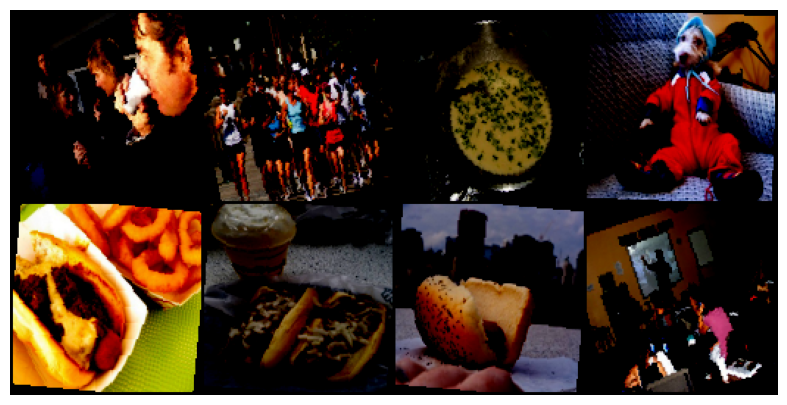

In [4]:
import os
import matplotlib.pyplot as plt
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Use the path from kagglehub.dataset_download, which is available globally.
# The 'path' variable is already set from the previous cell.

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(), # Data augmentation
    transforms.RandomRotation(15),    # Data augmentation
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

train_dataset = datasets.ImageFolder(
    root=os.path.join(path, 'train'),
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

print('Classes:', train_dataset.classes)
print('Num images:', len(train_dataset))

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 5))
grid = torchvision.utils.make_grid(images[:8], nrow=4)
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.show()

In [5]:
import torch
import torch.nn as nn

class FoodModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.net(x)

In [6]:
import torch.optim as optim
import numpy as np

food_model = FoodModel()

# Reduced learning rate and removed weight decay for better learning
optimizer = optim.AdamW(food_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [7]:
def train(model, optimizer, criterion, train_data, epochs = 10):
  loss_history = []
  model.train()
  for epoch in range(epochs):
    epoch_loss = []
    for x, y in train_data:
      optimizer.zero_grad()
      y_pred = model(x)
      loss = criterion(y_pred, y)

      loss_history += [loss.item()]
      epoch_loss += [loss.item()]

      loss.backward()
      optimizer.step()

    print(f"Epoch {epoch} loss: {np.mean(epoch_loss)}")

  return loss_history

In [8]:
loss_history = train(food_model, optimizer, criterion, train_loader, 50)

Epoch 0 loss: 0.6583303468341523
Epoch 1 loss: 0.6050332378833851
Epoch 2 loss: 0.5706490083260739
Epoch 3 loss: 0.5573814519225283
Epoch 4 loss: 0.5317353327223595
Epoch 5 loss: 0.5126048660975822
Epoch 6 loss: 0.4895202946314152
Epoch 7 loss: 0.4807684561039539
Epoch 8 loss: 0.46823346218530165
Epoch 9 loss: 0.4548784864551209
Epoch 10 loss: 0.4284674404783452
Epoch 11 loss: 0.41933844416858035
Epoch 12 loss: 0.40612856893146293
Epoch 13 loss: 0.384787218803738
Epoch 14 loss: 0.3640815875631698
Epoch 15 loss: 0.33671094445472066
Epoch 16 loss: 0.31856220893244797
Epoch 17 loss: 0.30295882025297655
Epoch 18 loss: 0.27169758941423383
Epoch 19 loss: 0.2799449175041407
Epoch 20 loss: 0.2429109611845714
Epoch 21 loss: 0.21620093789347944
Epoch 22 loss: 0.2129979489985457
Epoch 23 loss: 0.20912078892851763
Epoch 24 loss: 0.18542470765161387
Epoch 25 loss: 0.15505927302280165
Epoch 26 loss: 0.159250186320315
Epoch 27 loss: 0.14598573076271235
Epoch 28 loss: 0.13804561273254295
Epoch 29 loss

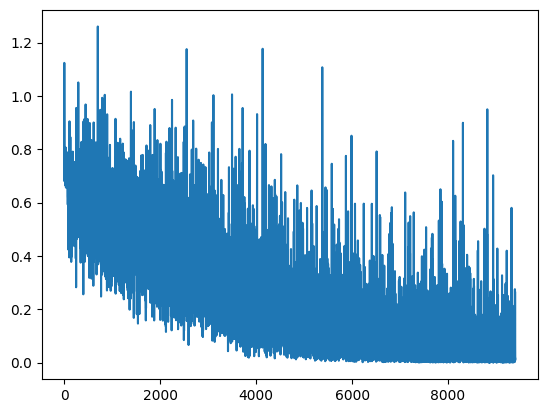

In [9]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.show()

In [10]:
import torch
import numpy as np

def evaluate(model, criterion, data_loader):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in data_loader:

            y_pred = model(x)

            loss = criterion(y_pred, y)
            total_loss += loss.item()

            preds = torch.argmax(y_pred, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total

    print(f"Eval loss: {avg_loss:.4f}")
    print(f"Accuracy: {accuracy:.4f}")

    return avg_loss, accuracy

In [11]:
test_dataset = datasets.ImageFolder(
    root=os.path.join(path, 'test'),
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=True
)

In [12]:
evaluate(food_model, criterion, test_loader)

Eval loss: 1.3570
Accuracy: 0.7516


(1.356967606740754, 0.7515527950310559)

In [13]:
len(test_loader)

41